# 模型的评估和改进 Judgement and Improvement of Models

## 模型评估
- 模型评估是机器学习中的关键步骤，用于衡量模型在训练数据和未见数据上的表现。
- 平方差误差（Mean Squared Error, MSE）是回归任务中常用的评估指标。
- 设训练集为$\{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{m_{train}}$，测试集为$\{(\mathbf{x}^{(j)}, y^{(j)})\}_{j=1}^{m_{test}}$，模型预测函数为$f(\mathbf{x})$，则训练误差和测试误差定义如下：
$$
MSE_{train} = \frac{1}{m_{train}} \sum_{i=1}^{m_{train}} (f(\mathbf{x}^{(i)}) - y^{(i)})^2
$$
$$
MSE_{test} = \frac{1}{m_{test}} \sum_{j=1}^{m_{test}} (f(\mathbf{x}^{(j)}) - y^{(j)})^2
$$
- 通过比较训练误差和测试误差，可以判断模型效果。
    - 若训练误差和测试误差都较低，说明模型表现良好。
    - 若训练误差较低但测试误差较高，说明模型过拟合。
    - 若训练误差和测试误差都较高，说明模型欠拟合。
- 对于逻辑回归，可以使用交叉熵损失（Cross-Entropy Loss）作为评估指标。
$$
J_{train} = - \frac{1}{m_{train}} \sum_{i=1}^{m_{train}} \left[ y^{(i)} \log(f(\mathbf{x}^{(i)})) + (1 - y^{(i)}) \log(1 - f(\mathbf{x}^{(i)})) \right]
$$
$$
J_{test} = - \frac{1}{m_{test}} \sum_{j=1}^{m_{test}} \left[ y^{(j)} \log(f(\mathbf{x}^{(j)})) + (1 - y^{(j)}) \log(1 - f(\mathbf{x}^{(j)})) \right]
$$

## 模型选择、交叉验证
- 模型选择是指在多个候选模型中选择最优模型的过程。
    - 例如，对于多项式回归，可以选择不同的多项式次数。
    - 但是，直接使用测试集进行模型选择会导致过拟合测试集。因为我们实际上在使用测试集的信息来选择模型（相当于拟合多项式次数）。
- 交叉验证（Cross-Validation）是一种常用的模型选择方法。
    - 例如，多项式回归，将训练集划分为3个子集，使用2个子集训练模型（training + cross validation），1个子集验证模型，重复3次，计算平均验证误差，选择平均验证误差最小的多项式次数。
    - 使用的误差就是$J_{train}$、$J_{cv}$。$J_{test}$只在最终评估时使用。

## 诊断偏差与方差
- 过拟合与欠拟合
    - 欠拟合时，$J_{train}$和$J_{cv}$都较高，说明模型复杂度不足，无法捕捉数据的模式。
    - 过拟合时，$J_{train}$较低但$J_{cv}$较高，说明模型复杂度过高，捕捉了训练数据中的噪声。
    - 过拟合与欠拟合的$J_{train}$与$J_{cv}$关系图：
![](./assets/bias-variance.png)

## 正则化与偏差方差
以四次多项式回归为例，对应的模型为：
$$
f_{\mathbf{w}, b}(\mathbf{x}) = w_4 x^4 + w_3 x^3 + w_2 x^2 + w_1 x + b
$$
成本函数为：
$$
J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{\mathbf{w}, b}(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m} \sum_{j=1}^{4} w_j^2
$$
观察不同正则化参数$\lambda$对偏差和方差的影响：
- 当$\lambda$过大时，正则化项的影响较大，$w_1, w_2$等参数被压缩得较小，模型变得简单，$f_{\mathbf{w}, b}(x) \to b$，可能导致欠拟合，$J_{train}$和$J_{cv}$都较高。
- 当$\lambda$过小时，正则化项的影响较小，模型复杂度较高，可能导致过拟合，$J_{train}$较低但$J_{cv}$较高。
如何利用交叉验证选择合适的$\lambda$：

对于cv集上的每个$\lambda$，计算对应的$J_{cv}(\lambda)$，选择使$J_{cv}(\lambda)$最小的$\lambda$作为最终的正则化参数。
最终可以得到不同$\lambda$对应的偏差-方差关系图：
![image.png](./assets/lambda-bias-variance.png)
可以看出，随着$\lambda$的增大，cv误差先减小后增大，train误差持续增大，存在一个最佳的$\lambda$值，使得模型在训练集和验证集上都表现良好。
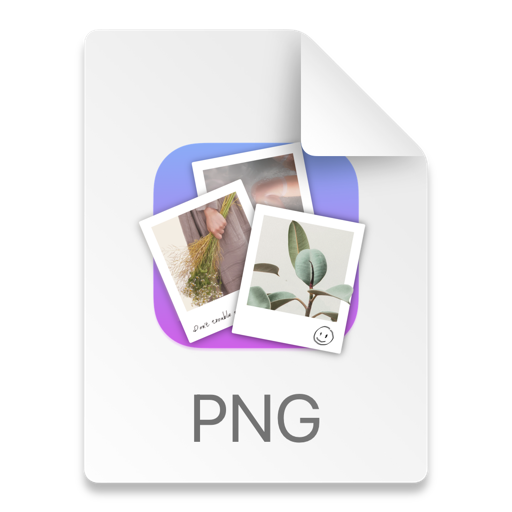
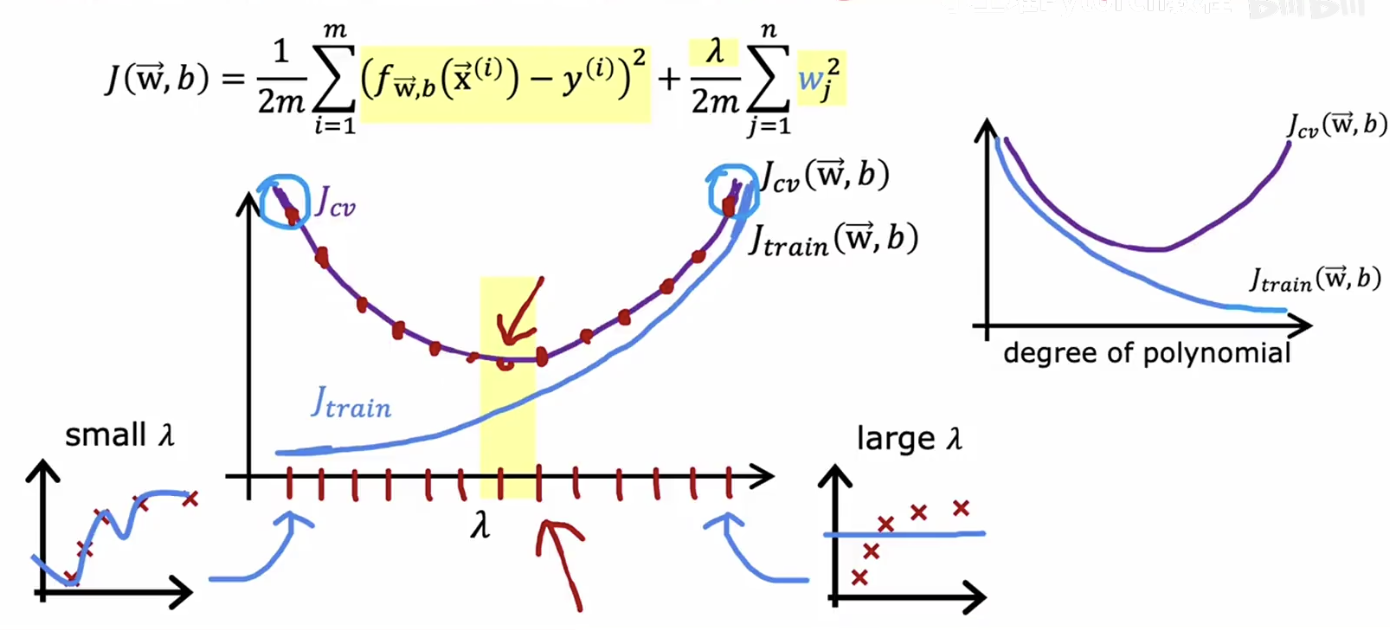
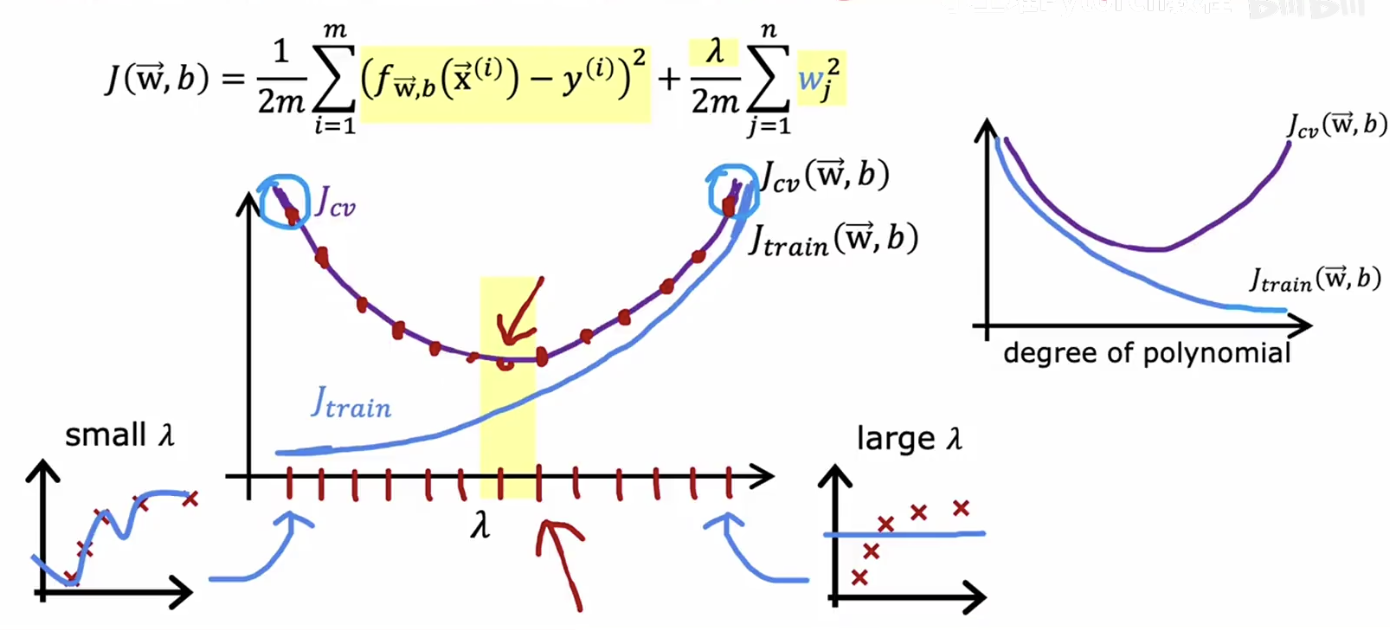

## 建立基准性能水平
基准性能水平（Baseline Performance Level）是指在开始构建复杂模型之前，期望达到的最低性能标准。建立基准性能水平有助于评估后续模型的改进效果。
例如，一个语音识别模型，人类的误差是10%，那么可以将10%作为基准性能水平。
- 如果$J_{train}$和$J_{cv}$都远高于基准水平，说明模型欠拟合（偏差太大），需要增加模型复杂度。
- 如果$J_{train}$低于基准水平或接近基准水平，但$J_{cv}$远高于基准水平，说明模型过拟合（方差太大），需要减少模型复杂度或增加正则化。

## 学习曲线
学习曲线（Learning Curve）是指随着训练样本数量的增加，模型在训练集和验证集上的误差变化情况。通过绘制学习曲线，可以帮助诊断模型的偏差和方差问题。
- 横轴表示训练样本数量$m$，纵轴表示误差$J_{train}(m)$和$J_{cv}(m)$。
- 一个典型的学习曲线如下所示：
![](./assets/learning-curve.png)
观察学习曲线的特点：
    - 随着训练样本数量$m$的增加，$J_{train}(m)$通常会增加，而$J_{cv}(m)$通常会减少。
    - 当$m$较小时，$J_{train}(m)$较低，$J_{cv}(m)$较高，说明模型在训练集上表现良好，但在验证集上表现较差，可能存在过拟合现象。
    - 当$m$较大时，$J_{train}(m)$和$J_{cv}(m)$趋于平稳，说明模型已经充分学习了数据的模式。
    - 通过增加训练样本数量，可以有效地减少过拟合现象，提高模型的泛化能力。
- 通过观察学习曲线，可以判断模型是否存在偏差或方差问题。
    - 如果$J_{train}(m)$和$J_{cv}(m)$趋于平稳的时候，二者相近，但都远高于基准水平，说明模型存在高偏差问题，欠拟合。
    - 如果趋于平稳的时候$J_{train}(m)$较低（甚至可以低于基准水平），但$J_{cv}(m)$较高，说明模型存在方差问题，过拟合。

当出现高偏差问题时，可以考虑增加模型复杂度（例如增加多项式次数），减少正则化参数$\lambda$等方法来改善模型性能；此时增加训练样本数量的效果不好。

当出现高方差问题时，可以考虑减少模型复杂度（例如减少多项式次数），增加正则化参数$\lambda$，或者增加训练样本数量来改善模型性能。

## 决定下一步做什么
1. 获取更多的训练样例：解决高方差问题
2. 尝试更小的特征集（减小模型复杂度）：解决高方差问题
3. 尝试获取额外的特征：解决高偏差问题
4. 尝试添加多项式特征：解决高变差问题
5. 减小$\lambda$：解决高偏差问题
6. 增大$\lambda$：解决高方差问题

## 偏差、方差与神经网络
大型神经网络在小型数据集上总是呈现出低偏差。一个简单的提升策略如图：
![](./assets/5-imprv1.png)
但这有如下缺陷：
1. 耗时，且成本高：训练神经网络特别是大型神经网络非常消耗资源
2. 不会总是获得足够的数据集

即便是大型的神经网络，如果正确地正则化了，那么可以做到和小型的神经网络一样好甚至更好。